
##  Model Explainability

### Objective

This notebook explains the predictions produced by the final
CancerGuard Support Vector Machine model.

Because the selected classifier uses an RBF kernel, its predictions
cannot be interpreted directly through simple model coefficients.
Therefore, model-agnostic explanation techniques are used.

The explainability workflow includes:

- Loading and validating the final trained SVM pipeline
- Global permutation feature importance
- SHAP-based global feature analysis
- Local explanation of individual predictions
- Explanation of correctly classified benign and malignant cases
- Investigation of false-negative and false-positive predictions
- Comparison of model explanations with previous feature-analysis findings

The final CancerGuard operating threshold is 0.30, selected using
out-of-fold training probabilities in the model evaluation stage.

In [14]:
### Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import shap


c:\Users\singh\anaconda3\envs\CancerGuard_Detection\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
### Load the dataset
df = pd.read_csv("D:/STUDY/Data_Science_Courses/PROJECTS/2.CancerGuard-SVM/CancerGuard---SVM-Cancer-Detection-API/data/Breast-Cancer_data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### Step 1 — Reproduce the Exact Dataset Split

In [3]:

df_clean = df.drop(columns=["id", "Unnamed: 32"]).copy()

df_clean["diagnosis"] = df_clean["diagnosis"].map({"B": 0,"M": 1})

X = df_clean.drop(columns=["diagnosis"])
y = df_clean["diagnosis"]

print("Dataset prepared successfully.")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset prepared successfully.
X shape: (569, 30)
y shape: (569,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set    :", X_test.shape)

print("\nTraining classes:")
print(y_train.value_counts().sort_index())

print("\nTest classes:")
print(y_test.value_counts().sort_index())

Training set: (455, 30)
Test set    : (114, 30)

Training classes:
diagnosis
0    285
1    170
Name: count, dtype: int64

Test classes:
diagnosis
0    72
1    42
Name: count, dtype: int64


### Step 2 — Load and Verify the Final SVM

#### 2.1 — Load pipeline

In [5]:
MODEL_PATH = "../models/final_svm_pipeline.pkl"

final_model = joblib.load(MODEL_PATH)

print("Final model loaded successfully.")
print()
print(final_model)

svm_model = final_model.named_steps["svm"]

print("Kernel       :", svm_model.kernel)
print("C            :", svm_model.C)
print("Gamma        :", svm_model.gamma)
print("Class Weight :", svm_model.class_weight)
print("Probability  :", svm_model.probability)

Final model loaded successfully.

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 SVC(C=10, class_weight='balanced', gamma=0.01,
                     probability=True, random_state=42))])
Kernel       : rbf
C            : 10
Gamma        : 0.01
Class Weight : balanced
Probability  : True


#### 2.2 — Reproduce Final Operating Predictions

In [6]:
## Reproduce Final Operating Predictions

OPERATING_THRESHOLD = 0.30

y_test_prob = final_model.predict_proba(X_test)[:, 1]

y_test_pred = (y_test_prob >= OPERATING_THRESHOLD).astype(int)

print("Operating threshold:", OPERATING_THRESHOLD)

print("\nPrediction distribution:")
print(
    pd.Series(y_test_pred)
    .value_counts()
    .sort_index()
)

Operating threshold: 0.3

Prediction distribution:
0    72
1    42
Name: count, dtype: int64


#### 2.3 — Build explainability results table

In [7]:
explanation_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred,
    "Malignant_Probability": y_test_prob
})

def classify_result(row):

    if row["Actual"] == 1 and row["Predicted"] == 1:
        return "True Positive"

    elif row["Actual"] == 0 and row["Predicted"] == 0:
        return "True Negative"

    elif row["Actual"] == 0 and row["Predicted"] == 1:
        return "False Positive"

    else:
        return "False Negative"


explanation_results["Result_Type"] = (
    explanation_results.apply(
        classify_result,
        axis=1
    )
)

print("Prediction outcome counts:")

print(
    explanation_results["Result_Type"]
    .value_counts()
)

display(explanation_results.head())

Prediction outcome counts:
Result_Type
True Negative     71
True Positive     41
False Negative     1
False Positive     1
Name: count, dtype: int64


,Actual,Predicted,Malignant_Probability,Result_Type
120,0,0,0.000255,True Negative
250,1,1,1.000000,True Positive
375,0,0,0.049391,True Negative
99,1,1,0.542556,True Positive
455,0,0,0.180040,True Negative


### Step 3 — Global Permutation Feature Importance

#### 3.1 — Calculate Permutation Importance

In [8]:
perm_result = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
})

permutation_df = (
    permutation_df
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Permutation importance calculated successfully.")
print("\nTop 15 features:")

display(permutation_df.head(15))

Permutation importance calculated successfully.

Top 15 features:


,Feature,Importance_Mean,Importance_Std
0,texture_worst,0.008322,0.004533
1,concavity_worst,0.003814,0.002531
2,texture_se,0.002205,0.001140
3,radius_worst,0.002017,0.002080
4,concave points_mean,0.002017,0.001998
5,area_worst,0.001687,0.001918
6,concavity_mean,0.001488,0.001845
7,smoothness_worst,0.001477,0.001344
8,perimeter_worst,0.001367,0.001659
9,concave points_worst,0.001224,0.001320


#### 3.2 — Plot Top 15 Features

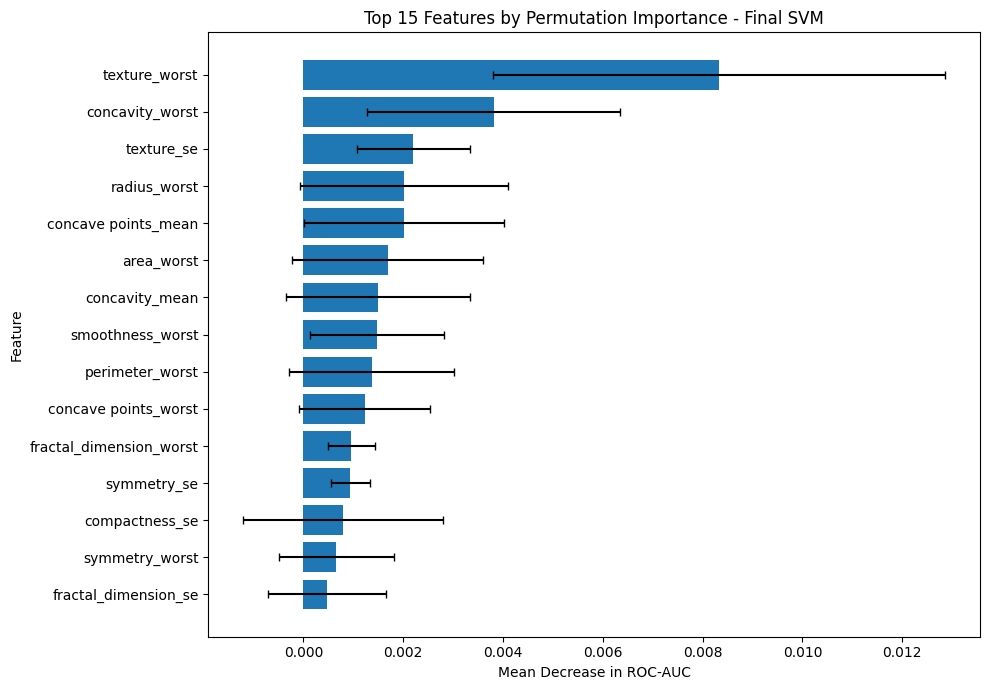

In [9]:
top_perm = permutation_df.head(15).sort_values(
    "Importance_Mean",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_perm["Feature"],
    top_perm["Importance_Mean"],
    xerr=top_perm["Importance_Std"],
    capsize=3
)

plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")

plt.title(
    "Top 15 Features by Permutation Importance - Final SVM"
)

plt.tight_layout()
plt.show()

#### 3.3 — Inspect All 30 Features

In [10]:
display(
    permutation_df.style.format({
        "Importance_Mean": "{:.6f}",
        "Importance_Std": "{:.6f}"
    })
)

,Feature,Importance_Mean,Importance_Std
0,texture_worst,0.008322,0.004533
1,concavity_worst,0.003814,0.002531
2,texture_se,0.002205,0.001140
3,radius_worst,0.002017,0.002080
4,concave points_mean,0.002017,0.001998
5,area_worst,0.001687,0.001918
6,concavity_mean,0.001488,0.001845
7,smoothness_worst,0.001477,0.001344
8,perimeter_worst,0.001367,0.001659
9,concave points_worst,0.001224,0.001320


### Step 4 — Compare Feature-Selection and Model-Importance Results

#### 4.1 — Create the comparison

In [11]:
# ============================================================
###  - COMPARE FEATURE IMPORTANCE METHODS
# ============================================================

anova_top15 = [
    "concave points_worst",
    "perimeter_worst",
    "radius_worst",
    "concave points_mean",
    "perimeter_mean",
    "area_worst",
    "radius_mean",
    "area_mean",
    "concavity_mean",
    "concavity_worst",
    "compactness_mean",
    "compactness_worst",
    "radius_se",
    "perimeter_se",
    "area_se"
]

mi_top15 = [
    "radius_worst",
    "perimeter_worst",
    "area_worst",
    "concave points_mean",
    "concave points_worst",
    "perimeter_mean",
    "area_mean",
    "radius_mean",
    "concavity_mean",
    "area_se",
    "concavity_worst",
    "perimeter_se",
    "radius_se",
    "compactness_worst",
    "compactness_mean"
]

perm_top15 = permutation_df.head(15)["Feature"].tolist()

comparison_features = sorted(
    set(anova_top15) |
    set(mi_top15) |
    set(perm_top15)
)

comparison_df = pd.DataFrame({
    "Feature": comparison_features
})

comparison_df["ANOVA_Top15"] = comparison_df["Feature"].isin(anova_top15)
comparison_df["MI_Top15"] = comparison_df["Feature"].isin(mi_top15)
comparison_df["Permutation_Top15"] = comparison_df["Feature"].isin(perm_top15)

comparison_df["Methods_Selected"] = (
    comparison_df[
        ["ANOVA_Top15", "MI_Top15", "Permutation_Top15"]
    ].sum(axis=1)
)

comparison_df = comparison_df.sort_values(
    ["Methods_Selected", "Feature"],
    ascending=[False, True]
).reset_index(drop=True)

display(comparison_df)

,Feature,ANOVA_Top15,MI_Top15,Permutation_Top15,Methods_Selected
0,area_worst,True,True,True,3
1,concave points_mean,True,True,True,3
2,concave points_worst,True,True,True,3
3,concavity_mean,True,True,True,3
4,concavity_worst,True,True,True,3
5,perimeter_worst,True,True,True,3
6,radius_worst,True,True,True,3
7,area_mean,True,True,False,2
8,area_se,True,True,False,2
9,compactness_mean,True,True,False,2


#### 4.2 — Find consensus features

In [12]:
consensus_features = comparison_df[
    comparison_df["Methods_Selected"] == 3
]["Feature"].tolist()

print("Features identified by ALL THREE methods:")
print(f"Number of consensus features: {len(consensus_features)}")

for feature in consensus_features:
    print(f"  - {feature}")

Features identified by ALL THREE methods:
Number of consensus features: 7
  - area_worst
  - concave points_mean
  - concave points_worst
  - concavity_mean
  - concavity_worst
  - perimeter_worst
  - radius_worst


#### 4.3 — Add actual permutation scores

In [13]:
comparison_detailed = comparison_df.merge(
    permutation_df[
        ["Feature", "Importance_Mean", "Importance_Std"]
    ],
    on="Feature",
    how="left"
)

comparison_detailed = comparison_detailed.sort_values(
    ["Methods_Selected", "Importance_Mean"],
    ascending=[False, False]
).reset_index(drop=True)

display(
    comparison_detailed.style.format({
        "Importance_Mean": "{:.6f}",
        "Importance_Std": "{:.6f}"
    })
)

,Feature,ANOVA_Top15,MI_Top15,Permutation_Top15,Methods_Selected,Importance_Mean,Importance_Std
0,concavity_worst,True,True,True,3,0.003814,0.002531
1,radius_worst,True,True,True,3,0.002017,0.002080
2,concave points_mean,True,True,True,3,0.002017,0.001998
3,area_worst,True,True,True,3,0.001687,0.001918
4,concavity_mean,True,True,True,3,0.001488,0.001845
5,perimeter_worst,True,True,True,3,0.001367,0.001659
6,concave points_worst,True,True,True,3,0.001224,0.001320
7,area_mean,True,True,False,2,0.000320,0.000997
8,perimeter_mean,True,True,False,2,0.000254,0.000926
9,radius_se,True,True,False,2,0.000243,0.001361


### Step 5 — Local Explainability with SHAP

#### 5.1 — Prepare SHAP model and background

In [15]:
# Representative training background
background = shap.sample(
    X_train,
    50,
    random_state=42
)

# Function returning probability of malignant class
def predict_malignant_probability(data):
    
    # KernelExplainer may provide NumPy arrays
    data_df = pd.DataFrame(
        data,
        columns=X_train.columns
    )
    
    return final_model.predict_proba(data_df)[:, 1]


explainer = shap.KernelExplainer(
    predict_malignant_probability,
    background
)

print("SHAP KernelExplainer created successfully.")
print("Background observations:", background.shape[0])
print("Number of features:", background.shape[1])

SHAP KernelExplainer created successfully.
Background observations: 50
Number of features: 30


#### 5.2 — Select clinically interesting test cases

In [18]:
# ============================================================
# RECREATE PREDICTION RESULTS FOR LOCAL EXPLAINABILITY
# ============================================================

# Operating threshold selected in Model Evaluation
OPERATING_THRESHOLD = 0.30

# Generate malignant probabilities
y_test_prob = final_model.predict_proba(X_test)[:, 1]

# Apply selected operating threshold
y_test_pred = (y_test_prob >= OPERATING_THRESHOLD).astype(int)

# Create results dataframe using original test indices
prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred,
    "Malignant_Probability": y_test_prob
}, index=X_test.index)

# Assign prediction outcome
def get_result_type(row):
    if row["Actual"] == 0 and row["Predicted"] == 0:
        return "True Negative"
    elif row["Actual"] == 1 and row["Predicted"] == 1:
        return "True Positive"
    elif row["Actual"] == 1 and row["Predicted"] == 0:
        return "False Negative"
    else:
        return "False Positive"

prediction_results["Result_Type"] = prediction_results.apply(
    get_result_type,
    axis=1
)

print("Prediction results recreated successfully.\n")

print("Prediction outcome counts:")
print(prediction_results["Result_Type"].value_counts())

display(prediction_results.head())

Prediction results recreated successfully.

Prediction outcome counts:
Result_Type
True Negative     71
True Positive     41
False Negative     1
False Positive     1
Name: count, dtype: int64


,Actual,Predicted,Malignant_Probability,Result_Type
120,0,0,0.000255,True Negative
250,1,1,1.000000,True Positive
375,0,0,0.049391,True Negative
99,1,1,0.542556,True Positive
455,0,0,0.180040,True Negative


#### 5.3 — Calculate SHAP values only for those cases

In [19]:
selected_cases = {}

for result_type in [
    "True Positive",
    "True Negative",
    "False Negative",
    "False Positive"
]:
    
    cases = prediction_results[
        prediction_results["Result_Type"] == result_type
    ]
    
    if len(cases) > 0:
        
        # Select one representative case
        if result_type == "True Positive":
            # High-confidence malignant prediction
            idx = cases["Malignant_Probability"].idxmax()
            
        elif result_type == "True Negative":
            # High-confidence benign prediction
            idx = cases["Malignant_Probability"].idxmin()
            
        else:
            # FN / FP: only one exists in your test set,
            # so simply select it
            idx = cases.index[0]
        
        selected_cases[result_type] = idx


print("Selected cases for local explanation:\n")

for case_type, idx in selected_cases.items():
    
    print(
        f"{case_type:15s} | "
        f"Index: {idx} | "
        f"Actual: {prediction_results.loc[idx, 'Actual']} | "
        f"Predicted: {prediction_results.loc[idx, 'Predicted']} | "
        f"Malignant Probability: "
        f"{prediction_results.loc[idx, 'Malignant_Probability']:.6f}"
    )

Selected cases for local explanation:

True Positive   | Index: 280 | Actual: 1 | Predicted: 1 | Malignant Probability: 1.000000
True Negative   | Index: 296 | Actual: 0 | Predicted: 0 | Malignant Probability: 0.000010
False Negative  | Index: 73 | Actual: 1 | Predicted: 0 | Malignant Probability: 0.051413
False Positive  | Index: 208 | Actual: 0 | Predicted: 1 | Malignant Probability: 0.312911


#### 5.4 — Calculate SHAP values for the 4 cases

In [20]:
# Extract selected observations
selected_indices = list(selected_cases.values())

X_selected = X_test.loc[selected_indices]

print("Selected observations:", selected_indices)
print("X_selected shape:", X_selected.shape)

# Calculate SHAP values
shap_values_selected = explainer.shap_values(X_selected)

print("\nSHAP values calculated successfully.")

# Check structure
print("Type:", type(shap_values_selected))

if isinstance(shap_values_selected, list):
    print("Number of outputs:", len(shap_values_selected))
    for i, values in enumerate(shap_values_selected):
        print(f"Output {i} shape:", values.shape)
else:
    print("SHAP values shape:", shap_values_selected.shape)

Selected observations: [np.int64(280), np.int64(296), np.int64(73), np.int64(208)]
X_selected shape: (4, 30)


100%|██████████| 4/4 [00:01<00:00,  2.61it/s]


SHAP values calculated successfully.
Type: <class 'numpy.ndarray'>
SHAP values shape: (4, 30)


#### 5.5 — Build SHAP Explanations

In [21]:
shap_values_array = np.asarray(shap_values_selected)

print("SHAP array shape:", shap_values_array.shape)
print("X_selected shape:", X_selected.shape)

assert shap_values_array.shape == X_selected.shape

print("SHAP dimensions validated successfully.")

SHAP array shape: (4, 30)
X_selected shape: (4, 30)
SHAP dimensions validated successfully.


In [22]:
expected_value = explainer.expected_value

print("SHAP expected value:", expected_value)

SHAP expected value: 0.24291965280333067


### Step 6 — Local Feature Contributions

#### 6.1 — Create local SHAP tables

In [23]:
local_explanations = {}

case_names = list(selected_cases.keys())

for i, case_name in enumerate(case_names):

    case_df = pd.DataFrame({
        "Feature": X_selected.columns,
        "Feature_Value": X_selected.iloc[i].values,
        "SHAP_Value": shap_values_array[i]
    })

    case_df["Abs_SHAP"] = case_df["SHAP_Value"].abs()

    case_df = case_df.sort_values(
        "Abs_SHAP",
        ascending=False
    ).reset_index(drop=True)

    local_explanations[case_name] = case_df

    print(f"\n{'='*70}")
    print(case_name)
    print(f"{'='*70}")

    display(case_df.head(10))


True Positive


,Feature,Feature_Value,SHAP_Value,Abs_SHAP
0,texture_worst,35.90000,0.110113,0.110113
1,radius_worst,23.72000,0.082496,0.082496
2,concave points_mean,0.09664,0.080116,0.080116
3,area_worst,1724.00000,0.079581,0.079581
4,concavity_worst,0.57540,0.078254,0.078254
5,perimeter_worst,159.80000,0.070608,0.070608
6,concavity_mean,0.19210,0.070474,0.070474
7,smoothness_worst,0.17820,0.065872,0.065872
8,perimeter_mean,126.20000,0.062686,0.062686
9,concave points_worst,0.18720,0.056880,0.056880



True Negative


,Feature,Feature_Value,SHAP_Value,Abs_SHAP
0,texture_worst,14.82000,-0.053307,0.053307
1,concavity_worst,0.02884,-0.029319,0.029319
2,texture_mean,12.35000,-0.025471,0.025471
3,radius_se,0.17530,-0.023506,0.023506
4,perimeter_se,1.26700,-0.020546,0.020546
5,radius_worst,11.37000,-0.019256,0.019256
6,area_worst,392.20000,-0.018887,0.018887
7,concave points_worst,0.03194,-0.017764,0.017764
8,symmetry_worst,0.21430,-0.017563,0.017563
9,concave points_mean,0.01369,-0.017291,0.017291



False Negative


,Feature,Feature_Value,SHAP_Value,Abs_SHAP
0,texture_worst,20.8600,-0.121282,0.121282
1,texture_mean,15.7900,-0.042288,0.042288
2,texture_se,0.6205,0.038615,0.038615
3,radius_se,0.2787,-0.021300,0.021300
4,symmetry_worst,0.2589,-0.017088,0.017088
5,concave points_worst,0.1383,0.014782,0.014782
6,perimeter_se,1.9570,-0.011955,0.011955
7,compactness_mean,0.1280,-0.011129,0.011129
8,area_se,23.3500,-0.010128,0.010128
9,compactness_worst,0.3542,-0.009734,0.009734



False Positive


,Feature,Feature_Value,SHAP_Value,Abs_SHAP
0,symmetry_worst,0.412800,0.109886,0.109886
1,compactness_se,0.030410,-0.056824,0.056824
2,compactness_worst,0.440200,-0.040092,0.040092
3,radius_se,0.193100,-0.036663,0.036663
4,texture_se,0.922300,0.032854,0.032854
5,fractal_dimension_se,0.004198,-0.031877,0.031877
6,concavity_worst,0.316200,0.026801,0.026801
7,concave points_mean,0.051020,0.026063,0.026063
8,texture_mean,22.540000,0.020148,0.020148
9,texture_worst,29.160000,0.019695,0.019695


#### 6.2 — Plot True Positive,True Negative,False Negative,False Positive Explanation

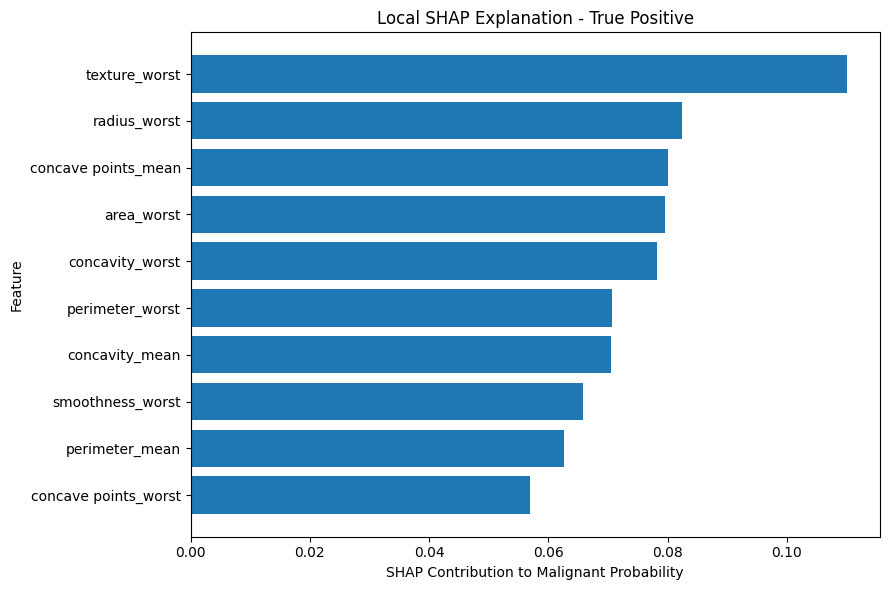

In [24]:
case_name = "True Positive"

tp_explanation = local_explanations[
    case_name
].head(10).sort_values("SHAP_Value")

plt.figure(figsize=(9, 6))

plt.barh(
    tp_explanation["Feature"],
    tp_explanation["SHAP_Value"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("SHAP Contribution to Malignant Probability")
plt.ylabel("Feature")

plt.title(
    "Local SHAP Explanation - True Positive"
)

plt.tight_layout()
plt.show()

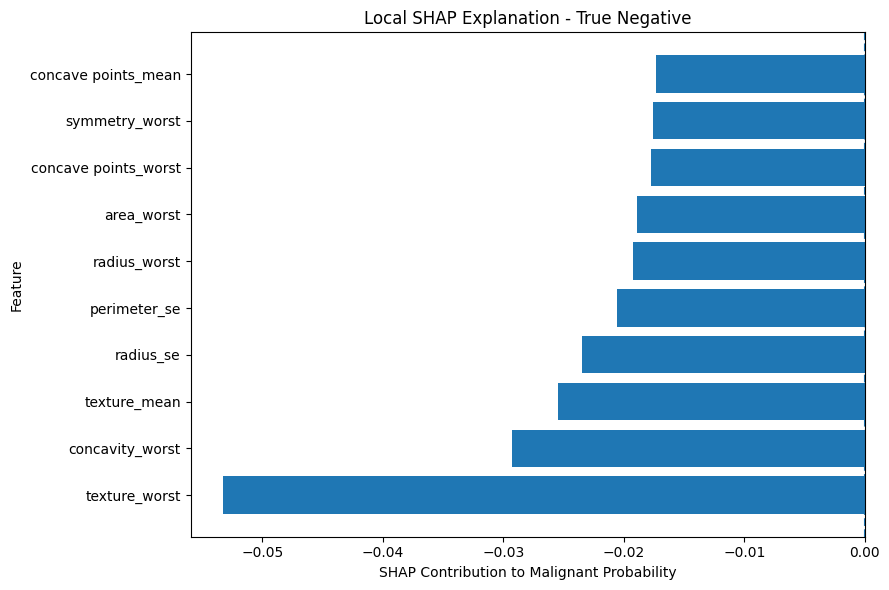

In [25]:
case_name = "True Negative"

tn_explanation = local_explanations[
    case_name
].head(10).sort_values("SHAP_Value")

plt.figure(figsize=(9, 6))

plt.barh(
    tn_explanation["Feature"],
    tn_explanation["SHAP_Value"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("SHAP Contribution to Malignant Probability")
plt.ylabel("Feature")

plt.title(
    "Local SHAP Explanation - True Negative"
)

plt.tight_layout()
plt.show()

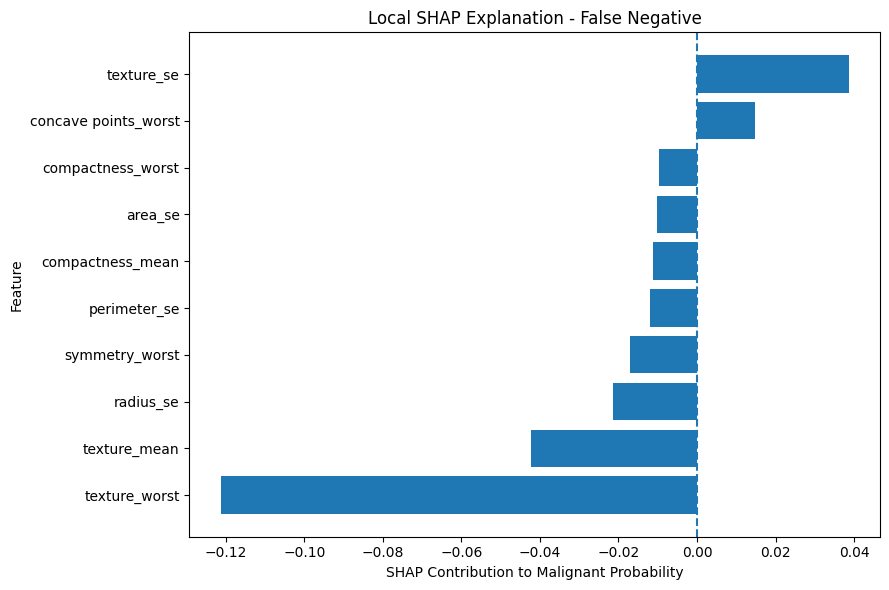

In [26]:
case_name = "False Negative"

fn_explanation = local_explanations[
    case_name
].head(10).sort_values("SHAP_Value")

plt.figure(figsize=(9, 6))

plt.barh(
    fn_explanation["Feature"],
    fn_explanation["SHAP_Value"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("SHAP Contribution to Malignant Probability")
plt.ylabel("Feature")

plt.title(
    "Local SHAP Explanation - False Negative"
)

plt.tight_layout()
plt.show()

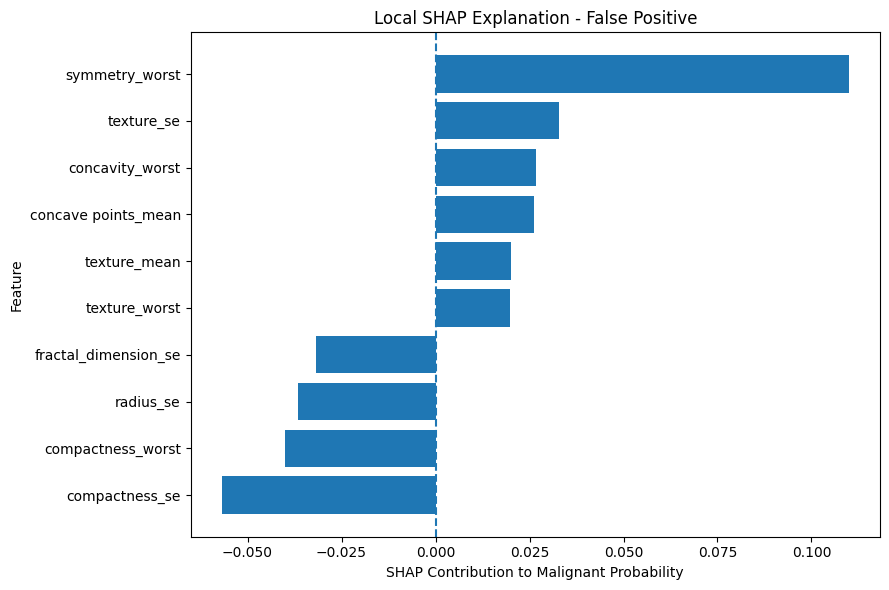

In [27]:
case_name = "False Positive"

fp_explanation = local_explanations[
    case_name
].head(10).sort_values("SHAP_Value")

plt.figure(figsize=(9, 6))

plt.barh(
    fp_explanation["Feature"],
    fp_explanation["SHAP_Value"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("SHAP Contribution to Malignant Probability")
plt.ylabel("Feature")

plt.title(
    "Local SHAP Explanation - False Positive"
)

plt.tight_layout()
plt.show()

### Step 7 — Global SHAP Explainability & Final Explainability Summary

#### 7.1 — Select a representative test sample

In [28]:
GLOBAL_SHAP_SAMPLE_SIZE = min(50, len(X_test))

X_shap_global = X_test.sample(
    n=GLOBAL_SHAP_SAMPLE_SIZE,
    random_state=42
)

print("Global SHAP sample created successfully.")
print("Number of observations:", len(X_shap_global))
print("Number of features:", X_shap_global.shape[1])
print("Shape:", X_shap_global.shape)

Global SHAP sample created successfully.
Number of observations: 50
Number of features: 30
Shape: (50, 30)


#### 7.2 — Calculate global SHAP values

In [29]:
global_shap_values = explainer.shap_values(X_shap_global)

global_shap_values = np.asarray(global_shap_values)

print("\nGlobal SHAP values calculated successfully.")
print("SHAP values shape:", global_shap_values.shape)
print("Feature matrix shape:", X_shap_global.shape)

assert global_shap_values.shape == X_shap_global.shape

print("Global SHAP dimensions validated successfully.")

100%|██████████| 50/50 [00:25<00:00,  1.96it/s]


Global SHAP values calculated successfully.
SHAP values shape: (50, 30)
Feature matrix shape: (50, 30)
Global SHAP dimensions validated successfully.


#### 7.3 — Global SHAP feature importance

In [30]:
global_shap_importance = pd.DataFrame({
    "Feature": X_shap_global.columns,
    "Mean_Abs_SHAP": np.abs(global_shap_values).mean(axis=0),
    "Std_Abs_SHAP": np.abs(global_shap_values).std(axis=0)
})

global_shap_importance = (
    global_shap_importance
    .sort_values("Mean_Abs_SHAP", ascending=False)
    .reset_index(drop=True)
)

global_shap_importance["SHAP_Rank"] = (
    np.arange(1, len(global_shap_importance) + 1)
)

print("Global SHAP Feature Importance:")
display(global_shap_importance)

Global SHAP Feature Importance:


,Feature,Mean_Abs_SHAP,Std_Abs_SHAP,SHAP_Rank
0,texture_worst,0.061003,0.051007,1
1,concave points_mean,0.039365,0.037976,2
2,concavity_worst,0.037867,0.043442,3
3,radius_worst,0.032935,0.034850,4
4,concavity_mean,0.030868,0.037635,5
5,area_worst,0.029900,0.036472,6
6,perimeter_worst,0.028216,0.030998,7
7,radius_se,0.026499,0.027762,8
8,texture_mean,0.020883,0.021826,9
9,concave points_worst,0.015863,0.025790,10


#### 7.4 — Plot Top 15 Global SHAP Features

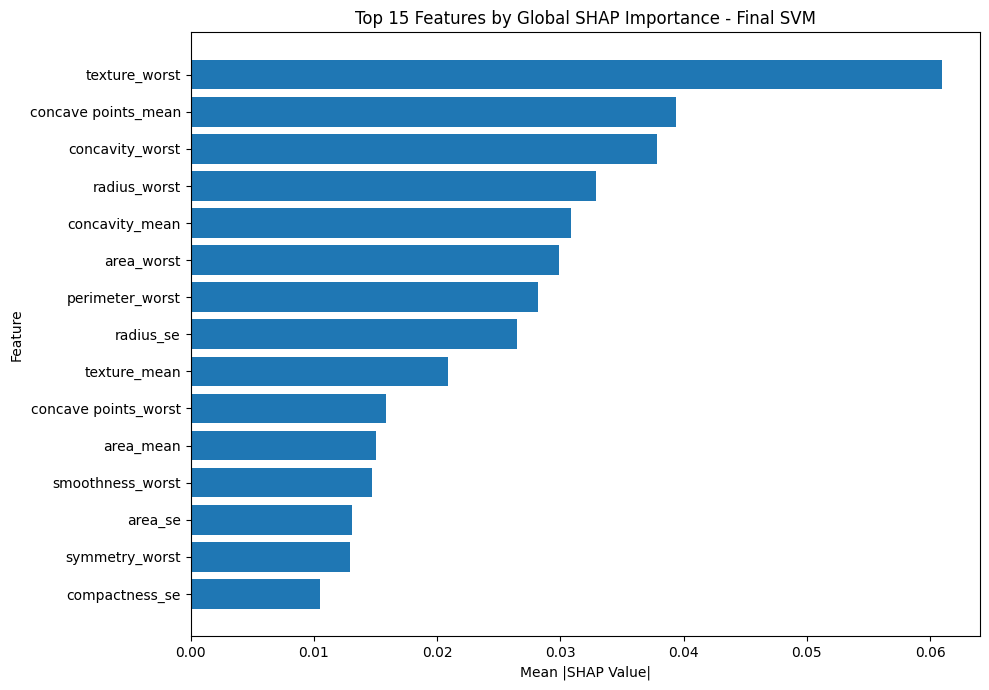

In [31]:

top15_global_shap = (
    global_shap_importance
    .head(15)
    .sort_values("Mean_Abs_SHAP")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top15_global_shap["Feature"],
    top15_global_shap["Mean_Abs_SHAP"]
)

plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Feature")

plt.title(
    "Top 15 Features by Global SHAP Importance - Final SVM"
)

plt.tight_layout()
plt.show()

#### 7.5 — SHAP Summary / Beeswarm Plot

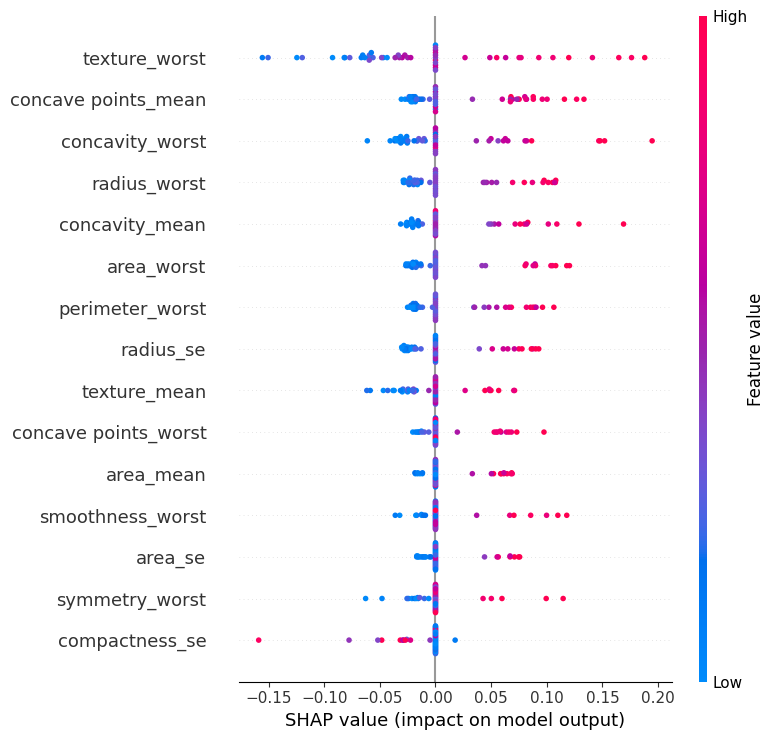

In [32]:
shap.summary_plot(
    global_shap_values,
    X_shap_global,
    feature_names=X_shap_global.columns,
    max_display=15,
    show=True
)

#### 7.6 — Compare SHAP vs Permutation Importance

In [33]:
permutation_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
})

shap_compare = global_shap_importance[
    ["Feature", "Mean_Abs_SHAP", "SHAP_Rank"]
].copy()

permutation_compare = permutation_importance_df[
    ["Feature", "Importance_Mean"]
].copy()

permutation_compare = permutation_compare.sort_values(
    "Importance_Mean",
    ascending=False
).reset_index(drop=True)

permutation_compare["Permutation_Rank"] = (
    np.arange(1, len(permutation_compare) + 1)
)

importance_comparison = shap_compare.merge(
    permutation_compare,
    on="Feature",
    how="inner"
)

importance_comparison["Average_Rank"] = (
    importance_comparison["SHAP_Rank"] +
    importance_comparison["Permutation_Rank"]
) / 2

importance_comparison = importance_comparison.sort_values(
    "Average_Rank"
).reset_index(drop=True)

display(
    importance_comparison.head(15)
)

,Feature,Mean_Abs_SHAP,SHAP_Rank,Importance_Mean,Permutation_Rank,Average_Rank
0,texture_worst,0.061003,1,0.008322,1,1.0
1,concavity_worst,0.037867,3,0.003814,2,2.5
2,concave points_mean,0.039365,2,0.002017,5,3.5
3,radius_worst,0.032935,4,0.002017,4,4.0
4,concavity_mean,0.030868,5,0.001488,7,6.0
5,area_worst,0.029900,6,0.001687,6,6.0
6,perimeter_worst,0.028216,7,0.001367,9,8.0
7,concave points_worst,0.015863,10,0.001224,10,10.0
8,smoothness_worst,0.014694,12,0.001477,8,10.0
9,texture_se,0.009829,17,0.002205,3,10.0


#### 7.7 — Compare SHAP with the 7 consensus features

In [34]:
consensus_features = [
    "area_worst",
    "concave points_mean",
    "concave points_worst",
    "concavity_mean",
    "concavity_worst",
    "perimeter_worst",
    "radius_worst"
]

consensus_shap_comparison = global_shap_importance[
    global_shap_importance["Feature"].isin(consensus_features)
].copy()

consensus_shap_comparison = (
    consensus_shap_comparison
    .sort_values("SHAP_Rank")
    .reset_index(drop=True)
)

print("Consensus features ranked by Global SHAP importance:")

display(consensus_shap_comparison)

Consensus features ranked by Global SHAP importance:


,Feature,Mean_Abs_SHAP,Std_Abs_SHAP,SHAP_Rank
0,concave points_mean,0.039365,0.037976,2
1,concavity_worst,0.037867,0.043442,3
2,radius_worst,0.032935,0.034850,4
3,concavity_mean,0.030868,0.037635,5
4,area_worst,0.029900,0.036472,6
5,perimeter_worst,0.028216,0.030998,7
6,concave points_worst,0.015863,0.025790,10


### Step 8 — Final Explainability Summary & Conclusions

In [35]:
final_explainability_summary = global_shap_importance[
    ["Feature", "Mean_Abs_SHAP", "SHAP_Rank"]
].merge(
    permutation_importance_df[
        ["Feature", "Importance_Mean"]
    ],
    on="Feature",
    how="left"
)

final_explainability_summary["Permutation_Rank"] = (
    final_explainability_summary["Importance_Mean"]
    .rank(ascending=False, method="min")
)

final_explainability_summary["Average_Rank"] = (
    final_explainability_summary["SHAP_Rank"] +
    final_explainability_summary["Permutation_Rank"]
) / 2

final_explainability_summary = (
    final_explainability_summary
    .sort_values("Average_Rank")
    .reset_index(drop=True)
)

print("Final Global Explainability Ranking:")
display(final_explainability_summary.head(15))

Final Global Explainability Ranking:


,Feature,Mean_Abs_SHAP,SHAP_Rank,Importance_Mean,Permutation_Rank,Average_Rank
0,texture_worst,0.061003,1,0.008322,1.0,1.0
1,concavity_worst,0.037867,3,0.003814,2.0,2.5
2,concave points_mean,0.039365,2,0.002017,5.0,3.5
3,radius_worst,0.032935,4,0.002017,4.0,4.0
4,concavity_mean,0.030868,5,0.001488,7.0,6.0
5,area_worst,0.029900,6,0.001687,6.0,6.0
6,perimeter_worst,0.028216,7,0.001367,9.0,8.0
7,concave points_worst,0.015863,10,0.001224,10.0,10.0
8,smoothness_worst,0.014694,12,0.001477,8.0,10.0
9,texture_se,0.009829,17,0.002205,3.0,10.0


In [36]:
## Final Consensus Features
final_consensus = global_shap_importance[
    global_shap_importance["Feature"].isin(consensus_features)
].copy()

final_consensus = (
    final_consensus
    .sort_values("SHAP_Rank")
    .reset_index(drop=True)
)

print("Final consensus features supported by:")
print("ANOVA + Mutual Information + Permutation Importance")
print("and ranked using Global SHAP\n")

display(
    final_consensus[
        ["Feature", "Mean_Abs_SHAP", "Std_Abs_SHAP", "SHAP_Rank"]
    ]
)

Final consensus features supported by:
ANOVA + Mutual Information + Permutation Importance
and ranked using Global SHAP



,Feature,Mean_Abs_SHAP,Std_Abs_SHAP,SHAP_Rank
0,concave points_mean,0.039365,0.037976,2
1,concavity_worst,0.037867,0.043442,3
2,radius_worst,0.032935,0.034850,4
3,concavity_mean,0.030868,0.037635,5
4,area_worst,0.029900,0.036472,6
5,perimeter_worst,0.028216,0.030998,7
6,concave points_worst,0.015863,0.025790,10


In [39]:
# ============================================================
#  Local Explanation Summary
# ============================================================

local_summary = []

for i, (case_name, original_index) in enumerate(selected_cases.items()):

    row = prediction_results.loc[original_index]

    case_shap = pd.DataFrame({
        "Feature": X_test.columns,
        "SHAP_Value": shap_values_array[i]
    })

    case_shap["Abs_SHAP"] = case_shap["SHAP_Value"].abs()

    top_feature = (
        case_shap
        .sort_values("Abs_SHAP", ascending=False)
        .iloc[0]
    )

    local_summary.append({
        "Case": case_name,
        "Index": original_index,
        "Actual": int(row["Actual"]),
        "Predicted": int(row["Predicted"]),
        "Malignant_Probability": row["Malignant_Probability"],
        "Most_Influential_Feature": top_feature["Feature"],
        "SHAP_Value": top_feature["SHAP_Value"]
    })

local_summary_df = pd.DataFrame(local_summary)

print("Local SHAP Explanation Summary:")
display(local_summary_df)

Local SHAP Explanation Summary:


,Case,Index,Actual,Predicted,Malignant_Probability,Most_Influential_Feature,SHAP_Value
0,True Positive,280,1,1,1.000000,texture_worst,0.110113
1,True Negative,296,0,0,0.000010,texture_worst,-0.053307
2,False Negative,73,1,0,0.051413,texture_worst,-0.121282
3,False Positive,208,0,1,0.312911,symmetry_worst,0.109886


###  Model Interpretation Conclusions

The explainability analysis provides both global and local evidence for understanding the final RBF-SVM classifier.

#### Global interpretation

Global SHAP analysis identified `texture_worst` as the most influential feature overall. Other highly influential features included `concave points_mean`, `concavity_worst`, `radius_worst`, `concavity_mean`, `area_worst`, and `perimeter_worst`.

The SHAP summary plot showed that higher values of several important tumour morphology features generally increased the model output toward the malignant class, whereas lower values tended to reduce the malignant prediction.

#### Agreement between explanation methods

Permutation importance and Global SHAP showed substantial agreement in their highest-ranked features. In particular, `texture_worst`, `concavity_worst`, `radius_worst`, and `area_worst` ranked highly under both approaches.

Seven features were also consistently identified by ANOVA, Mutual Information, and Permutation Importance:

- `concave points_mean`
- `concavity_worst`
- `radius_worst`
- `concavity_mean`
- `area_worst`
- `perimeter_worst`
- `concave points_worst`

All seven also appeared among the higher-ranked Global SHAP features, providing additional evidence that these variables are important to the final model.

#### Local interpretation

SHAP explanations were generated for four representative prediction outcomes: True Positive, True Negative, False Negative, and False Positive.

The True Positive case contained multiple features contributing strongly toward malignant classification, while the True Negative case was dominated by features contributing away from malignancy.

The False Negative analysis was particularly important because the malignant observation received strong negative contributions from features such as `texture_worst`, reducing the predicted malignant probability below the selected operating threshold.

The False Positive case demonstrated the opposite behaviour, where features including `symmetry_worst` produced positive contributions strong enough to move a benign observation above the malignant classification threshold.

These local explanations demonstrate how combinations of feature contributions can lead to both correct classifications and clinically important model errors.

### Explainability Limitations

Although the explainability analysis provides useful insight into the final SVM model, several limitations should be considered.

1. **RBF-SVM is a nonlinear black-box model.**  
   Unlike linear models or decision trees, the final classifier does not provide directly interpretable coefficients or decision rules.

2. **SHAP explanations are approximations.**  
   Kernel SHAP estimates feature contributions by repeatedly evaluating the model and therefore provides an approximation of the model's behaviour rather than a direct representation of its internal decision function.

3. **Feature correlation can affect importance estimates.**  
   Several breast tumour measurements, including radius, perimeter, area, concavity, and concave-point variables, are related. Importance can therefore be distributed across correlated predictors.

4. **Permutation importance measures predictive dependence rather than causality.**  
   A high permutation importance score indicates that disrupting a feature reduces model performance; it does not establish that the feature causes malignancy.

5. **SHAP values should not be interpreted as causal effects.**  
   Positive SHAP values indicate contributions toward the model's malignant output, while negative SHAP values indicate contributions away from it. They do not establish clinical causation.

6. **Global SHAP was calculated using a sample of observations.**  
   A sample of 50 observations was used to control the computational cost of Kernel SHAP. The global explanation therefore represents the selected sample rather than an exhaustive SHAP calculation over every observation.

7. **Model explanations are decision-support information.**  
   The explanations describe the behaviour of the trained machine-learning model and should not be interpreted as independent clinical diagnoses or medical evidence.